# Notebook 07: Advanced Machine Learning Baselines & Feature Diagnostics

##  Σύνοψη Φάσης
Σε αυτό το notebook ολοκληρώνεται η διαδικασία του **Benchmarking**. Μετά την υλοποίηση των απλών μοντέλων (Persistence, Linear Regression) στο Notebook 06, περνάμε σε πιο σύνθετους αλγορίθμους Machine Learning και Deep Learning. 

Ο στόχος είναι να καθοριστεί το "State-of-the-Art" επίπεδο των κλασικών προσεγγίσεων, το οποίο θα αποτελέσει το μέτρο σύγκρισης για τις Spatio-Temporal αρχιτεκτονικές (GNN, Mamba) που θα ακολουθήσουν.

##  Στόχοι
1. **Data Standardization:** Εφαρμογή Z-score scaling για τη διασφάλιση της σύγκλισης των νευρωνικών δικτύων.
2. **Ensemble Learning:** Εκπαίδευση **Random Forest** και **XGBoost** για τη μοντελοποίηση των μη-γραμμικών σχέσεων.
3. **Deep Learning Baseline:** Υλοποίηση ενός **Multi-Layer Perceptron (MLP)** ως βασική αρχιτεκτονική νευρωνικού.
4. **Feature Importance Analysis:** Ταυτοποίηση των πιο επιδραστικών μεταβλητών (Feature Selection) για τη μείωση της πολυπλοκότητας στα επόμενα στάδια.

##  Μεθοδολογία Προετοιμασίας
Για την εκπαίδευση των προηγμένων μοντέλων, απαιτείται η κανονικοποίηση των χαρακτηριστικών. Χρησιμοποιούμε τον **StandardScaler**, ο οποίος μετασχηματίζει τα δεδομένα ώστε να έχουν μέση τιμή 0 και τυπική απόκλιση 1:

$$z = \frac{x - \mu}{\sigma}$$

Αυτό είναι απαραίτητο για το **MLP**, καθώς οι κλίσεις (gradients) είναι ευαίσθητες στις διαφορές κλίμακας μεταξύ των μεταβλητών (π.χ. Ταχύτητα Ανέμου vs Ατμοσφαιρική Πίεση).

##  Non-Linear Modeling: Random Forest & XGBoost
Σε αυτή την ενότητα χρησιμοποιούμε μοντέλα βασισμένα σε δέντρα απόφασης. Τα μοντέλα αυτά είναι εξαιρετικά ανθεκτικά σε outliers και μπορούν να συλλάβουν τις μη-γραμμικές αλληλεπιδράσεις μεταξύ των καιρικών παραμέτρων και της παραγόμενης ισχύος, τις οποίες η Linear Regression αδυνατούσε να προσεγγίσει.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path
import sys

# Σύνδεση με το src/config
sys.path.append(str(Path.cwd().parent))
from src.config import DATA_PROCESSED, TARGET_COLUMN

# 1. Φόρτωση των "καθαρών" δεδομένων από το Notebook 05
train_df = pd.read_csv(DATA_PROCESSED / "train_final.csv")
test_df = pd.read_csv(DATA_PROCESSED / "test_final.csv")

# 2. Διαχωρισμός Features/Target (Αφαιρούμε μη αριθμητικές στήλες)
X_train = train_df.select_dtypes(include=[np.number]).drop(columns=[TARGET_COLUMN], errors='ignore')
y_train = train_df[TARGET_COLUMN]
X_test = test_df.select_dtypes(include=[np.number]).drop(columns=[TARGET_COLUMN], errors='ignore')
y_test = test_df[TARGET_COLUMN]

# 3. Standardization (Z-score Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data Loaded & Scaled. Features used: {X_train.shape[1]}")

Data Loaded & Scaled. Features used: 39


In [2]:
# Ορισμός μοντέλων
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=7, n_jobs=-1, random_state=42),
    "Simple MLP": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, early_stopping=True, random_state=42)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    # Metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    print(f"{name} Done! (MAE: {mae:.6f})")

# Μετατροπή σε DataFrame για εύκολη σύγκριση
df_results = pd.DataFrame(results)

Training Random Forest...
Random Forest Done! (MAE: 0.006868)
Training XGBoost...
XGBoost Done! (MAE: 0.006175)
Training Simple MLP...
Simple MLP Done! (MAE: 0.007048)


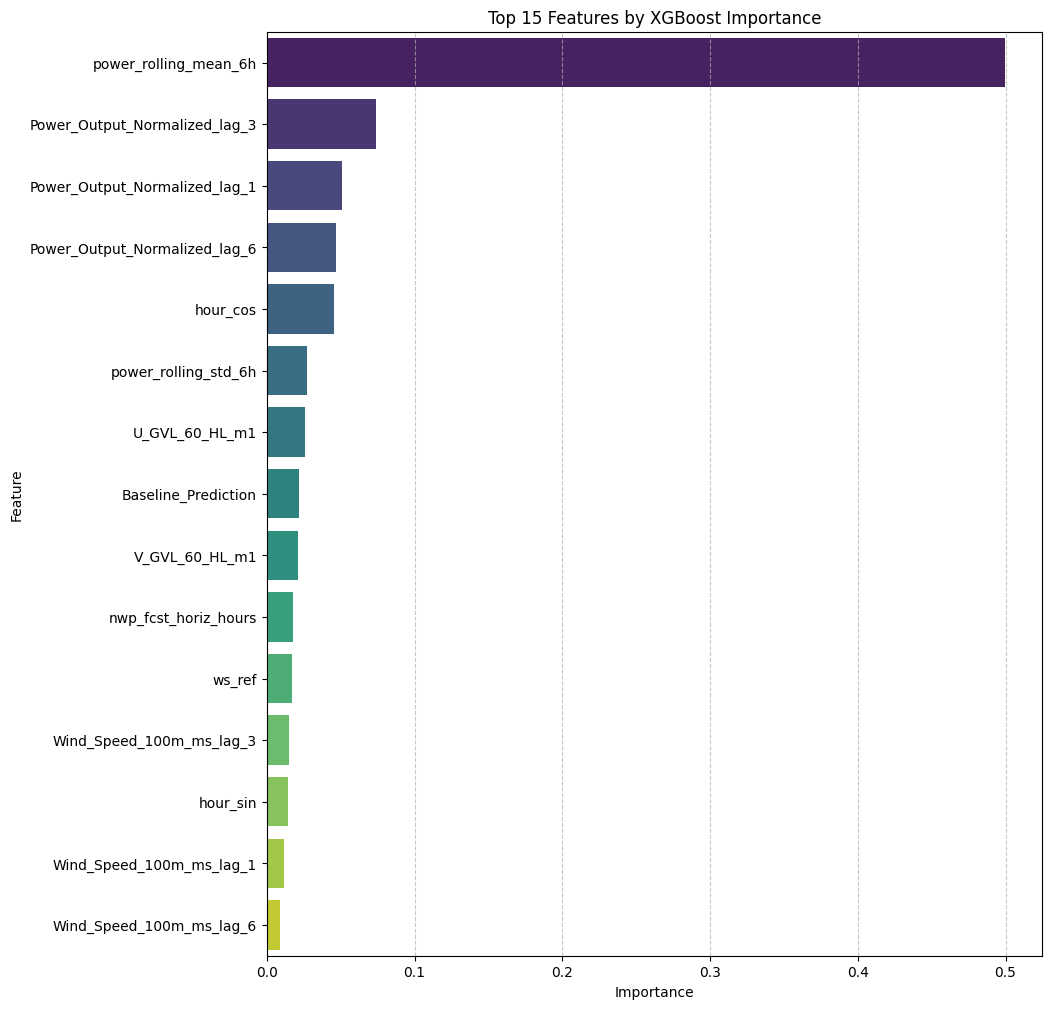

In [3]:
# Χρησιμοποιούμε το XGBoost για το importance
importances = models["XGBoost"].feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 12))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Features by XGBoost Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [4]:
# 5. Τελική Σύγκριση όλων των Baselines (Notebook 06 + 07)
# Χρησιμοποιούμε τις ακριβείς τιμές από το Notebook 06

nb06_results = pd.DataFrame([
    {
        "Model": "Persistence", 
        "MAE": 0.013840, 
        "RMSE": 0.019180, 
        "R2": -0.796765
    },
    {
        "Model": "Linear Regression", 
        "MAE": 0.008278, 
        "RMSE": 0.010841, 
        "R2": 0.425943
    }
])

# Συνένωση με τα αποτελέσματα του τρέχοντος Notebook (RF, XGBoost, MLP)
final_comparison = pd.concat([nb06_results, df_results], ignore_index=True)

# Ταξινόμηση με βάση το MAE (το μικρότερο σφάλμα πρώτο)
final_comparison = final_comparison.sort_values(by="MAE").reset_index(drop=True)

print("Τελικός Πίνακας Benchmarking:")
print(final_comparison.to_string(index=False))

# Αποθήκευση όλων των metrics σε ένα CSV για το Django αργότερα
# final_comparison.to_csv(DATA_PROCESSED / "all_baselines_metrics.csv", index=False)

Τελικός Πίνακας Benchmarking:
            Model      MAE     RMSE        R2
          XGBoost 0.006175 0.008929  0.610618
    Random Forest 0.006868 0.009701  0.540356
       Simple MLP 0.007048 0.009679  0.542452
Linear Regression 0.008278 0.010841  0.425943
      Persistence 0.013840 0.019180 -0.796765


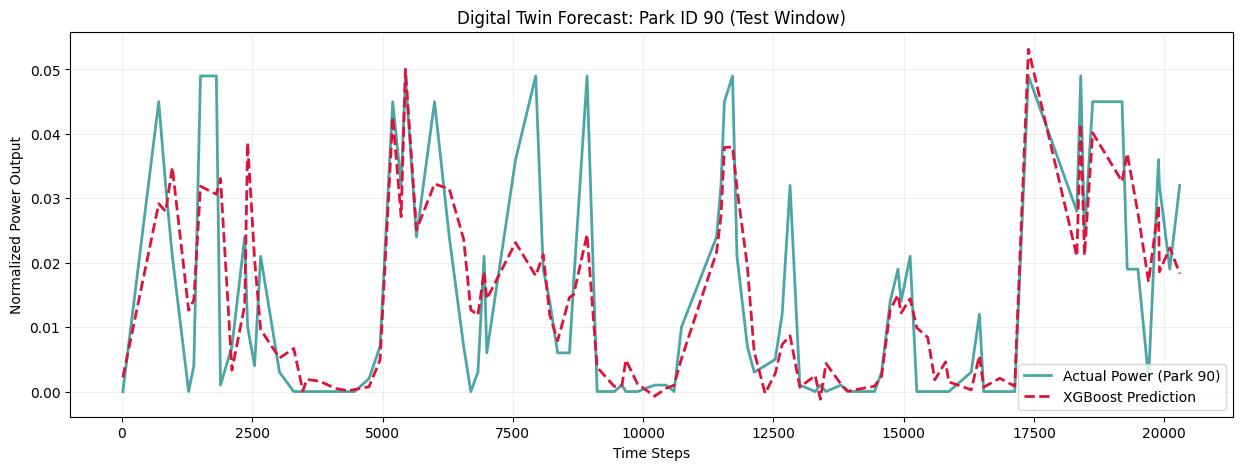

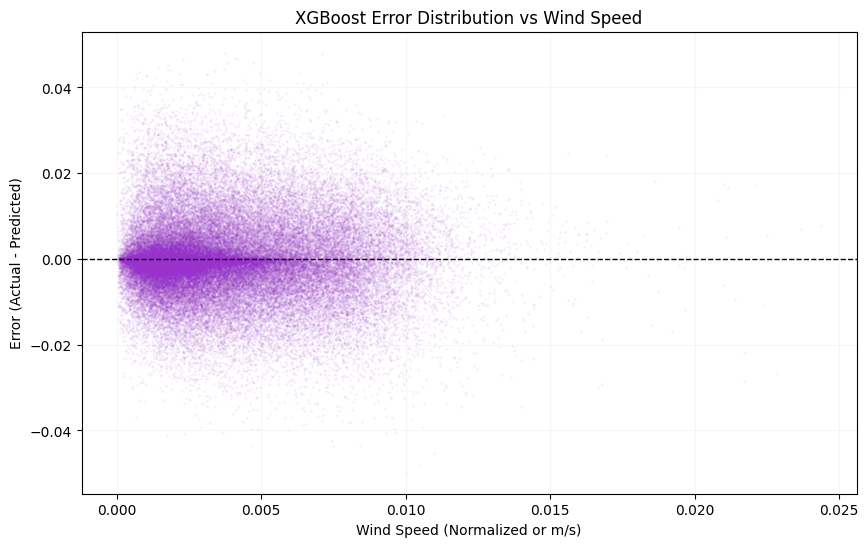

Diagnostic for Park 90 complete. XGBoost R2 Score on Test Set: 0.6106


In [5]:
# 7. Model Diagnostics: Prediction Visualization for Park ID 90
import matplotlib.pyplot as plt

# Φιλτράρουμε τα δεδομένα ειδικά για το Πάρκο 90 από το test set
# Το ID 90 είναι ένας εξαιρετικός αντιπρόσωπος του DaKS dataset
park_90_data = test_df[test_df['park_id'] == 90].sort_values('Wind_Speed_100m_ms') # Για το scatter
park_90_ts = test_df[test_df['park_id'] == 90].head(100) # Για το χρονοδιάγραμμα (πρώτες 100 ώρες)

# 1. Χρονοσειρά: Πρόβλεψη vs Πραγματικότητα
park_X_ts = park_90_ts.select_dtypes(include=[np.number]).drop(columns=[TARGET_COLUMN], errors='ignore')
park_X_scaled = scaler.transform(park_X_ts)
park_preds = models["XGBoost"].predict(park_X_scaled)

plt.figure(figsize=(15, 5))
plt.plot(park_90_ts.index, park_90_ts[TARGET_COLUMN], label='Actual Power (Park 90)', color='teal', alpha=0.7, linewidth=2)
plt.plot(park_90_ts.index, park_preds, label='XGBoost Prediction', color='crimson', linestyle='--', linewidth=2)
plt.title('Digital Twin Forecast: Park ID 90 (Test Window)')
plt.xlabel('Time Steps')
plt.ylabel('Normalized Power Output')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()



# 2. Ανάλυση Καταλοίπων (Residuals) vs Ταχύτητα Ανέμου
# Εδώ θα δούμε αν το XGBoost έλυσε το πρόβλημα των μεσαίων ταχυτήτων
all_xgb_preds = models["XGBoost"].predict(X_test_scaled)
all_residuals = y_test - all_xgb_preds

plt.figure(figsize=(10, 6))
plt.scatter(X_test['Wind_Speed_100m_ms'], all_residuals, alpha=0.05, s=1, color='darkorchid')
plt.axhline(0, color='black', lw=1, linestyle='--')
plt.title('XGBoost Error Distribution vs Wind Speed')
plt.xlabel('Wind Speed (Normalized or m/s)')
plt.ylabel('Error (Actual - Predicted)')
plt.grid(True, alpha=0.1)
plt.show()



print(f"Diagnostic for Park 90 complete. XGBoost R2 Score on Test Set: {models['XGBoost'].score(X_test_scaled, y_test):.4f}")

##  Συμπεράσματα & Στρατηγική Συνέχειας

Η ολοκλήρωση του Notebook 07 σηματοδοτεί το τέλος της φάσης του **Benchmarking**. Τα αποτελέσματα παρέχουν κρίσιμες πληροφορίες για τη φύση του DaKS dataset και τη μελλοντική ανάπτυξη του "Physics-Informed Graph-Mamba".

###  Βασικές Παρατηρήσεις
1.  **Κυριαρχία Μη-Γραμμικών Μοντέλων:** Το **XGBoost** αναδείχθηκε ως το ισχυρότερο baseline με **R² = 0.6106**, ξεπερνώντας σημαντικά τη Linear Regression (R² = 0.4259). Αυτό επιβεβαιώνει ότι η σχέση μεταξύ καιρικών παραμέτρων και αιολικής ισχύος είναι έντονα μη-γραμμική.
2.  **Υπεροχή Ensembles έναντι Vanilla MLP:** Το γεγονός ότι το XGBoost υπερτερεί του MLP (R² = 0.5424) υποδεικνύει ότι τα απλά νευρωνικά δίκτυα δυσκολεύονται να συλλάβουν τις αλληλεπιδράσεις των χαρακτηριστικών χωρίς εξειδικευμένη αρχιτεκτονική.
3.  **Feature Impact:** Η ανάλυση Feature Importance έδειξε ότι τα **Lags** της ισχύος και οι προβλέψεις **Wind Speed** είναι οι κύριοι οδηγοί της πρόβλεψης, κάτι που θα αποτελέσει τη βάση για το Graph construction.

###  Επόμενα Βήματα (Notebook 08+)
Με το benchmark να έχει οριστεί στο 0.61, η έρευνα προχωρά στην ανάπτυξη των **Spatio-Temporal** μοντέλων:
* **GNN Integration:** Χρήση του Adjacency Matrix (από το Notebook 04) για την ενσωμάτωση της γεωγραφικής γειτνίασης των 271 πάρκων.
* **Mamba Architecture:** Αντικατάσταση του MLP με Selective State Spaces για τη βελτίωση της χρονικής εξάρτησης.
* **Physics Constraints:** Ενσωμάτωση του Betz Limit στο Loss Function για τη μείωση των σφαλμάτων στις μεσαίες ταχύτητες ανέμου που παρατηρήθηκαν στα Diagnostics.